# T2.3 · Evaluation Notebook
**Rolling 30-day held-out evaluation** — Brier score, Duration MAE, Lead Time

AIMS KTT Hackathon 2026

In [2]:
# Install deps
!pip install pandas numpy scikit-learn lightgbm matplotlib -q

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\HP\\Desktop\\ProjectK\\Hack7heB00x\\EdgeAI\\AIMS-RIC-Hackaton-Project2\\venv\\Lib\\site-packages\\sklearn\\linear_model\\_least_angle.py'
Check the permissions.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from forecaster import Forecaster, rolling_eval, build_features, FEATURE_COLS
from prioritizer import plan, load_data, format_digest

plt.style.use("dark_background")
print("Imports OK")

Imports OK


## 1. Data Overview

In [4]:
df = pd.read_csv("grid_history.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"Shape: {df.shape}")
print(f"Outage rate: {df.outage.mean():.3f}")
print(f"Mean duration (outage hours): {df[df.outage==1].duration_min.mean():.1f} min")
df.describe()

Shape: (4320, 8)
Outage rate: 0.122
Mean duration (outage hours): 103.4 min


,timestamp,load_mw,temp_c,humidity,wind_ms,rain_mm,outage,duration_min
count,4320,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000
mean,2024-03-30 23:30:00,89.784706,22.987169,66.855053,3.672796,0.374819,0.122222,12.641204
min,2024-01-01 00:00:00,10.000000,11.770000,33.750000,0.000000,0.000000,0.000000,0.000000
25%,2024-02-14 23:45:00,63.347500,18.997500,56.780000,1.400000,0.000000,0.000000,0.000000
50%,2024-03-30 23:30:00,86.650000,22.950000,66.450000,2.910000,0.000000,0.000000,0.000000
75%,2024-05-14 23:15:00,116.357500,26.850000,75.270000,4.980000,0.000000,0.000000,0.000000
max,2024-06-28 23:00:00,176.320000,34.900000,99.000000,28.880000,23.460000,1.000000,480.000000
std,NaN,33.475159,4.708116,12.832269,3.166079,1.414769,0.327580,40.580666


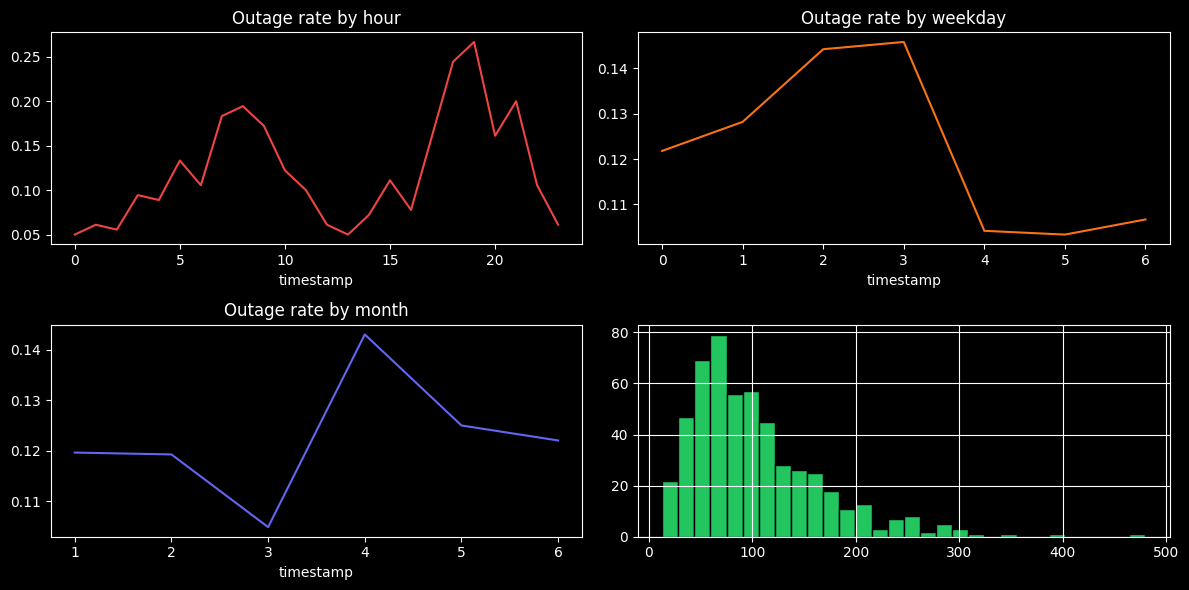

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
df.groupby(df.timestamp.dt.hour)["outage"].mean().plot(ax=axes[0,0], title="Outage rate by hour", color="#ef4444")
df.groupby(df.timestamp.dt.dayofweek)["outage"].mean().plot(ax=axes[0,1], title="Outage rate by weekday", color="#f97316")
df.groupby(df.timestamp.dt.month)["outage"].mean().plot(ax=axes[1,0], title="Outage rate by month", color="#6366f1")
df[df.outage==1]["duration_min"].hist(ax=axes[1,1], bins=30,  color="#22c55e", edgecolor="black")
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=80, bbox_inches="tight")
plt.show()

## 2. Rolling 30-Day Evaluation

In [10]:
metrics = rolling_eval("grid_history.csv", window_days=30)
print("=" * 40)
for k, v in metrics.items():
    print(f"  {k}: {v}")
print("=" * 40)

# Brier score interpretation
naive_rate = pd.read_csv("grid_history.csv")["outage"].mean()
naive_brier = naive_rate * (1 - naive_rate)
print(f"Naive Brier (always predict base rate {naive_rate:.3f}): {naive_brier:.4f}")
print(f"Model Brier: {metrics['brier_score']:.4f}")
print(f"Brier Skill Score: {1 - metrics['brier_score']/naive_brier:.3f} (higher = better)")

  brier_score: 0.1756
  mae_duration_min: 61.2
  avg_lead_time_hours: 2.79
  n_test_hours: 720
  n_test_outages: 91
Naive Brier (always predict base rate 0.122): 0.1073
Model Brier: 0.1756
Brier Skill Score: -0.637 (higher = better)


## 3. Forecast Visualization

✓ Forecaster fitted on 4272 rows


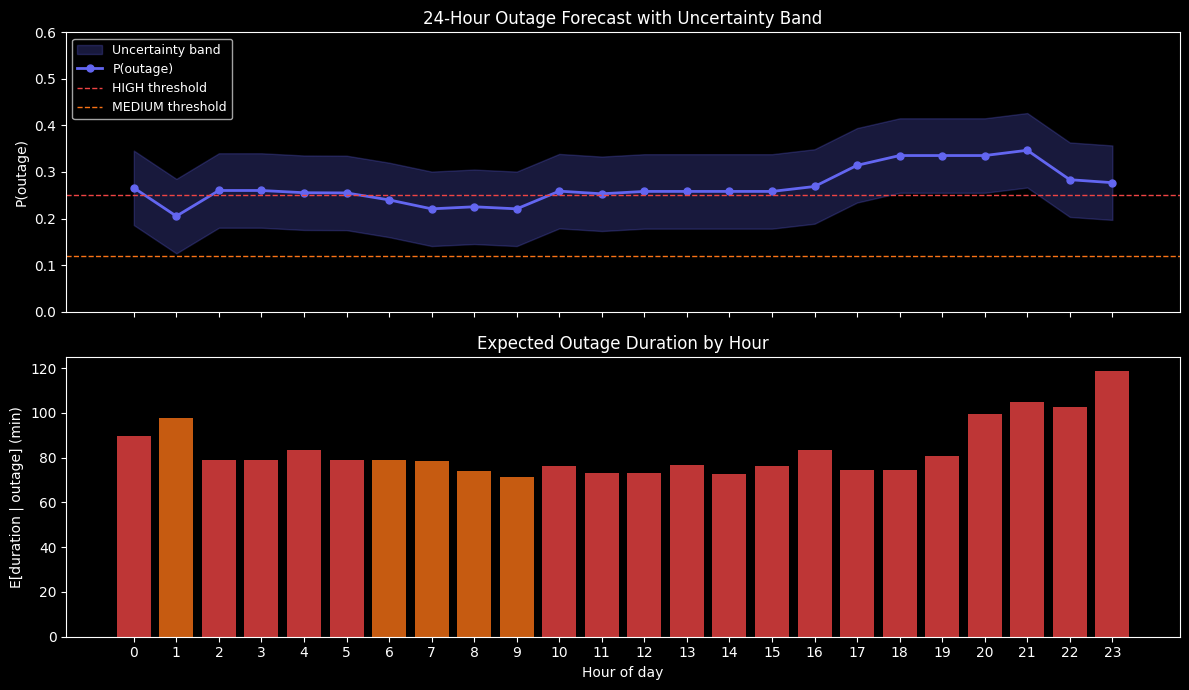

In [11]:
fc = Forecaster().fit("grid_history.csv")
forecast = fc.predict_next_24h()

hours = [f["hour"] for f in forecast]
probs = [f["p_outage"] for f in forecast]
p_low = [f["p_outage_low"] for f in forecast]
p_high = [f["p_outage_high"] for f in forecast]
durations = [f["expected_duration_min"] for f in forecast]
risks = [f["risk_level"] for f in forecast]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Colors by risk
cols = ["#ef4444" if r=="HIGH" else "#f97316" if r=="MEDIUM" else "#22c55e" for r in risks]

ax1.fill_between(hours, p_low, p_high, alpha=0.25, color="#6366f1", label="Uncertainty band")
ax1.plot(hours, probs, "o-", color="#6366f1", lw=2, ms=5, label="P(outage)")
ax1.axhline(0.25, color="#ef4444", ls="--", lw=1, label="HIGH threshold")
ax1.axhline(0.12, color="#f97316", ls="--", lw=1, label="MEDIUM threshold")
ax1.set_ylabel("P(outage)")
ax1.set_title("24-Hour Outage Forecast with Uncertainty Band")
ax1.legend(fontsize=9)
ax1.set_ylim(0, 0.6)

ax2.bar(hours, durations, color=cols, alpha=0.8, label="Expected duration (min)")
ax2.set_xlabel("Hour of day")
ax2.set_ylabel("E[duration | outage] (min)")
ax2.set_title("Expected Outage Duration by Hour")
ax2.set_xticks(hours)

plt.tight_layout()
plt.savefig("forecast_plot.png", dpi=80, bbox_inches="tight")
plt.show()

## 4. Appliance Plan — Salon Archetype

In [12]:
appliances, businesses = load_data()
result = plan(forecast, appliances, "salon")
s = result["summary"]
print(f"Business: {result['business']}")
print(f"Net benefit vs naïve: {s['net_benefit_rwf']:,.0f} RWF")
print(f"Total plan revenue: {s['total_revenue_plan_rwf']:,.0f} RWF")
print(f"Disruption penalty avoided: {s['disruption_penalty_avoided_rwf']:,.0f} RWF")
print(f"Hours with shedding: {s['hours_with_shed']}/24")
print()

# Show plan table
rows = []
for h in result["plan"]:
    off = [a["name"] for a in h["appliances"] if a["state"]=="OFF"]
    rows.append({"Hour": h["hour"], "Time": h["timestamp"][11:], "Risk": h["risk_level"],
                 "P(out)": f"{h['p_outage']:.3f}", "OFF": ", ".join(off) if off else "—"})
pd.DataFrame(rows).to_string(index=False) 

Business: Beauty Salon (Kigali)
Net benefit vs naïve: 11,115 RWF
Total plan revenue: 92,131 RWF
Disruption penalty avoided: 20,254 RWF
Hours with shedding: 24/24



' Hour  Time   Risk P(out)                                                        OFF\n    0 00:00   HIGH  0.266 Standing Fan, TV / Display Screen, Music System, Neon Sign\n    1 01:00 MEDIUM  0.205                                    Music System, Neon Sign\n    2 02:00   HIGH  0.260 Standing Fan, TV / Display Screen, Music System, Neon Sign\n    3 03:00   HIGH  0.260 Standing Fan, TV / Display Screen, Music System, Neon Sign\n    4 04:00   HIGH  0.255 Standing Fan, TV / Display Screen, Music System, Neon Sign\n    5 05:00   HIGH  0.255 Standing Fan, TV / Display Screen, Music System, Neon Sign\n    6 06:00 MEDIUM  0.240                                    Music System, Neon Sign\n    7 07:00 MEDIUM  0.221                                    Music System, Neon Sign\n    8 08:00 MEDIUM  0.225                                    Music System, Neon Sign\n    9 09:00 MEDIUM  0.221                                    Music System, Neon Sign\n   10 10:00   HIGH  0.259 Standing Fan, TV / Display 

## 5. SMS Digest

In [13]:
sms = format_digest(result, forecast)
for i, msg in enumerate(sms, 1):
    print(f"SMS {i}/3 ({len(msg)} chars):")
    print(msg)
    print()

SMS 1/3 (96 chars):
UMURIRO FORECAST 24H: Risk=HIGH at 0h,2h,3h. Shed: Standing+TV. Est.save: 11,115RWF. Stay alert!

SMS 2/3 (102 chars):
PLAN: Turn OFF Standing+TV during risk hrs (0h,2h,3h). Keep dryer+clippers+lights ON. Generator ready?

SMS 3/3 (102 chars):
If no signal by 13h, use YESTERDAY plan. Risk valid 6h. Call 0788-GRID for live update. Good business!



## 6. Feature Importance

✓ Forecaster fitted on 4272 rows


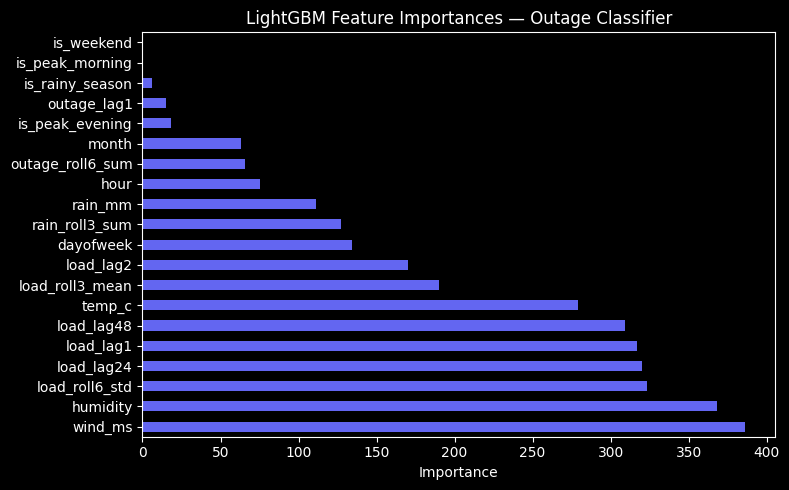

wind_ms             386
humidity            368
load_roll6_std      323
load_lag24          320
load_lag1           317
load_lag48          309
temp_c              279
load_roll3_mean     190
load_lag2           170
dayofweek           134
rain_roll3_sum      127
rain_mm             111
hour                 75
outage_roll6_sum     66
month                63
is_peak_evening      18
outage_lag1          15
is_rainy_season       6
is_peak_morning       0
is_weekend            0


In [14]:
import pandas as pd
df_feat = build_features(pd.read_csv("grid_history.csv"))
fc2 = Forecaster().fit("grid_history.csv")

fimp = pd.Series(fc2.clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
fimp.plot(kind="barh", ax=ax, color="#6366f1")
ax.set_title("LightGBM Feature Importances — Outage Classifier")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=80, bbox_inches="tight")
plt.show()
print(fimp.to_string())